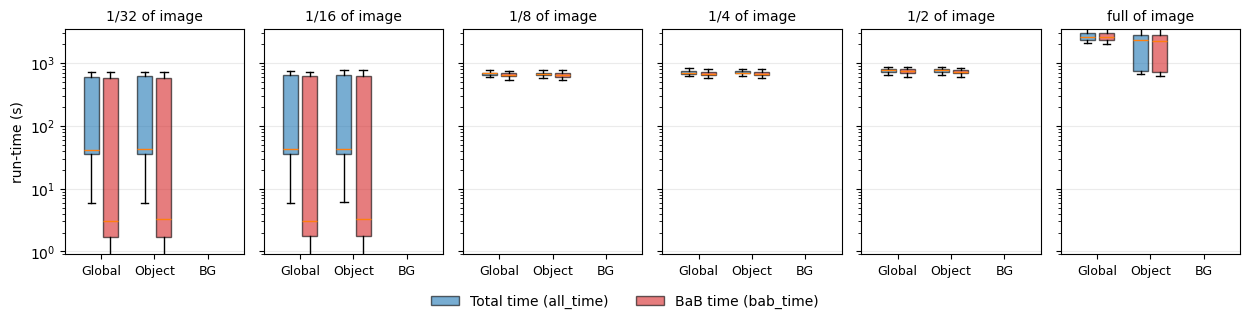

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =============================
# Load + tidy
# =============================
CSV_PATH = "csvs/ALL_vggnet_triplets_merged.csv"   # <- change
OUT_DIR  = "pdfs"                                 # <- change

df = pd.read_csv(CSV_PATH)

TAG2SEM = {
    "global": "Global",
    "fix_nonmask": "Object",
    "fix_mask": "Background",
}
df["Semantic"] = df["tag"].map(TAG2SEM).fillna(df["tag"].astype(str))

for c in ["k", "eps", "all_time", "bab_time"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["k", "eps", "all_time", "bab_time"])
df = df[(df["all_time"] > 0) & (df["bab_time"] > 0)]

SEM_ORDER = ["Global", "Object", "BG"]


# =============================
# Map k → fraction label
# =============================
FULL_K = df["k"].max()

def k_to_fraction(k):
    ratio = FULL_K / k
    if ratio == 1:
        return "full"
    return f"1/{int(ratio)}"


# =============================
# Plot
# =============================
def plot_all_vs_bab(df, eps_value=0.0001):

    dfx = df[df["eps"] == eps_value].copy()
    k_values = sorted(dfx["k"].unique())

    n = len(k_values)
    fig, axes = plt.subplots(1, n, figsize=(2.1*n, 3.2), sharey=True)

    if n == 1:
        axes = [axes]

    # shared y-limits
    yvals = np.concatenate([dfx["all_time"].values, dfx["bab_time"].values])
    yvals = yvals[yvals > 0]
    ylo = np.percentile(yvals, 1)
    yhi = np.percentile(yvals, 99)

    for i, k in enumerate(k_values):
        ax = axes[i]
        d_k = dfx[dfx["k"] == k]

        centers = np.arange(1, 4)
        dx = 0.18

        data_all = []
        data_bab = []

        for sem in SEM_ORDER:
            s_all = d_k[d_k["Semantic"] == sem]["all_time"]
            s_bab = d_k[d_k["Semantic"] == sem]["bab_time"]
            data_all.append(s_all.values)
            data_bab.append(s_bab.values)

        bp1 = ax.boxplot(
            data_all,
            positions=centers - dx,
            widths=0.28,
            patch_artist=True,
            showfliers=False
        )

        bp2 = ax.boxplot(
            data_bab,
            positions=centers + dx,
            widths=0.28,
            patch_artist=True,
            showfliers=False
        )

        for b in bp1["boxes"]:
            b.set_facecolor("C0")
            b.set_alpha(0.6)

        for b in bp2["boxes"]:
            b.set_facecolor("C3")
            b.set_alpha(0.6)

        ax.set_xticks(centers)
        ax.set_xticklabels(SEM_ORDER, fontsize=9)

        ax.set_yscale("log")
        ax.set_ylim(ylo, yhi)

        frac_label = k_to_fraction(k)
        ax.set_title(f"{frac_label} of image", fontsize=10)

        ax.grid(axis="y", alpha=0.25)

        if i == 0:
            ax.set_ylabel("run-time (s)")

    legend_handles = [
        Patch(facecolor="C0", edgecolor="black", alpha=0.6, label="Total time (all_time)"),
        Patch(facecolor="C3", edgecolor="black", alpha=0.6, label="BaB time (bab_time)")
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02)
    )

    fig.tight_layout(rect=[0, 0.07, 1, 1])

    fig.savefig(os.path.join(OUT_DIR, "all_vs_bab_by_k_fraction.pdf"), bbox_inches="tight")

    plt.show()


# =============================
# Run
# =============================
plot_all_vs_bab(df, eps_value=0.0001)

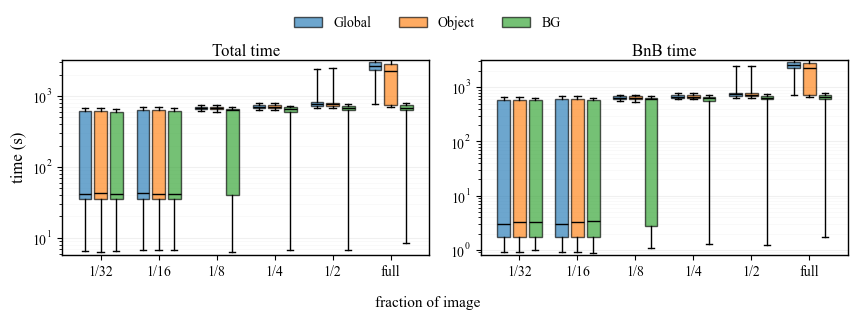

Saved: pdfs/total_vs_bab_boxplots_imagenet.pdf


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator, LogFormatterMathtext

# ==============================
# Elegant paper style
# ==============================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ==============================
# Paths
# ==============================
CSV_PATH = "csvs/ALL_vggnet_triplets_merged.csv"   # <- change if needed
OUT_DIR  = "pdfs"
os.makedirs(OUT_DIR, exist_ok=True)

# ==============================
# Load + tidy
# ==============================
df = pd.read_csv(CSV_PATH)

TAG2SEM = {
    "global": "Global",
    "fix_nonmask": "Object",
    "fix_mask": "BG",   # background
}
df["Semantic"] = df["tag"].map(TAG2SEM).fillna(df["tag"].astype(str))

for c in ["k", "eps", "all_time", "bab_time"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["k", "eps", "all_time", "bab_time", "Semantic"])
df = df[(df["all_time"] > 0) & (df["bab_time"] > 0)]

SEM_ORDER = ["Global", "Object", "BG"]

# ==============================
# Map k -> fraction label
# ==============================
FULL_K = int(df["k"].max())

def k_to_fraction_label(k: int) -> str:
    ratio = FULL_K / float(k)
    rint = int(round(ratio))
    if abs(ratio - rint) < 1e-6:
        return "full" if rint == 1 else f"1/{rint}"
    return f"{k}/{FULL_K}"

def frac_sort_key(k: int) -> float:
    # sort left->right as 1/32,1/16,...,full  (bigger ratio first)
    return FULL_K / float(k)

# ==============================
# Helper: robust y-lims
# ==============================
def robust_log_ylim(vals: np.ndarray):
    vals = np.asarray(vals)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    lo = np.percentile(vals, 2)
    hi = np.percentile(vals, 98)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo <= 0:
        lo, hi = np.min(vals), np.max(vals)
    return lo * 0.9, hi * 1.1

# ==============================
# Plot: 2-panel boxplots (Total vs BaB)
# ==============================
def plot_two_panel_boxplots(df_in: pd.DataFrame, eps_value=0.0001, out_pdf="total_vs_bab_boxplots.pdf"):
    dfx = df_in[df_in["eps"] == eps_value].copy()
    if dfx.empty:
        raise ValueError(
            f"No rows for eps={eps_value}. "
            f"Available eps (first 10): {sorted(df_in['eps'].dropna().unique())[:10]}"
        )

    # fractions (k values) ordered small->full
    k_vals = sorted(dfx["k"].unique(), key=frac_sort_key, reverse=True)  # 1/32 ... full
    frac_labels = [k_to_fraction_label(int(k)) for k in k_vals]

    n = len(k_vals)
    x = np.arange(n)  # group index

    # positions: 3 semantics inside each group
    offsets = np.array([-0.27, 0.0, 0.27])
    width = 0.22

    colors = {"Global": "C0", "Object": "C1", "BG": "C2"}

    # figure size: readable but not huge
    fig_w = max(6.2, 0.75 * n + 4.0)
    fig, axes = plt.subplots(1, 2, figsize=(fig_w, 3.0), sharex=True)

    def draw(ax, col, title):
        # y-lims (robust)
        ylo, yhi = robust_log_ylim(dfx[col].to_numpy())

        for j, sem in enumerate(SEM_ORDER):
            data = []
            positions = []
            for i, k in enumerate(k_vals):
                vals = dfx[(dfx["k"] == k) & (dfx["Semantic"] == sem)][col].dropna().to_numpy()
                data.append(vals)
                positions.append(x[i] + offsets[j])

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width,
                patch_artist=True,
                showfliers=False,
                manage_ticks=False,
                whis=(5, 95),  # nicer whiskers than default
            )

            for box in bp["boxes"]:
                box.set_facecolor(colors[sem])
                box.set_alpha(0.65)
                box.set_edgecolor("black")
                box.set_linewidth(1.0)

            for elem in ["whiskers", "caps", "medians"]:
                for line in bp[elem]:
                    line.set_color("black")
                    line.set_linewidth(1.0)

        ax.set_title(title, pad=3)
        ax.set_yscale("log")
        ax.set_ylim(ylo, yhi)

        # log ticks (nice math formatting)
        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

        # subtle grid only on y
        ax.grid(axis="y", which="major", alpha=0.18, linewidth=0.8)
        ax.grid(axis="y", which="minor", alpha=0.08, linewidth=0.6)
        ax.grid(axis="x", alpha=0.0)

    draw(axes[0], "all_time", "Total time")
    draw(axes[1], "bab_time", "BnB time")

    # x ticks at group centers
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(frac_labels)
    axes[0].set_ylabel("time (s)")
    fig.text(0.5, 0.02, "fraction of image", ha="center", va="center")

    # one clean legend (outside, centered on top)
    handles = [Patch(facecolor=colors[s], edgecolor="black", alpha=0.65, label=s) for s in SEM_ORDER]
    fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

    plt.subplots_adjust(left=0.07, right=0.995, top=0.83, bottom=0.18, wspace=0.14)

    out_path = os.path.join(OUT_DIR, out_pdf)
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

# ==============================
# Run
# ==============================
plot_two_panel_boxplots(df, eps_value=0.0001, out_pdf="total_vs_bab_boxplots_imagenet.pdf")

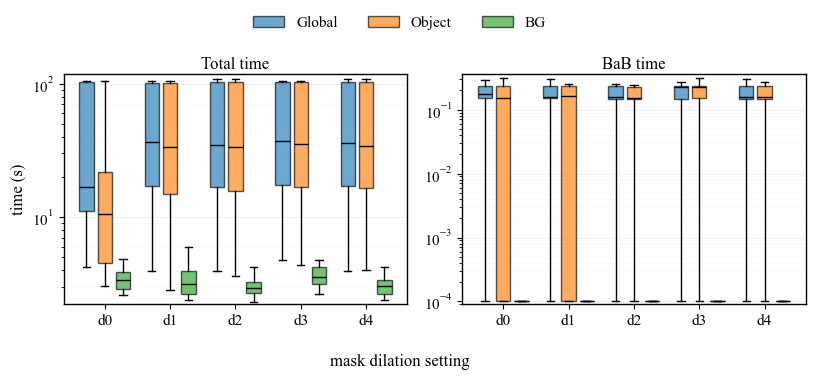

Saved: pdfs_cifar100/cifar100_d0_d4_total_vs_bab_boxplot.pdf


In [20]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator, LogFormatterMathtext

# ==============================
# Style
# ==============================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ==============================
# Config
# ==============================
BASE_DIR = "../results"
EXPERIMENTS = [
    "cifar100_segmented",        # d0
    "cifar100_segmented_d_1",    # d1
    "cifar100_segmented_d_2",    # d2
    "cifar100_segmented_d_3",    # d3
    "cifar100_segmented_d_4",    # d4
]
CSV_NAME = "combined_results.csv"
OUT_DIR = "pdfs_cifar100"
os.makedirs(OUT_DIR, exist_ok=True)

SEM_ORDER = ["Global", "Object", "BG"]
COLORS = {"Global": "C0", "Object": "C1", "BG": "C2"}

# for log-scale BaB time, we need a positive number
BAB_FLOOR = 1e-4  # 0.0001s (shows "no BaB" cases near the floor)

# ==============================
# Helpers
# ==============================
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def dilation_from_experiment(exp_name: str) -> int:
    m = re.search(r"_d_(\d+)", exp_name)
    return int(m.group(1)) if m else 0

def normalize_semantic(df: pd.DataFrame) -> pd.DataFrame:
    """
    EXACT mapping you want (same as your reference):
      global       -> Global
      fix_nonmask  -> Object
      fix_mask     -> BG
    """
    if "Semantic" in df.columns:
        return df

    if "tag" in df.columns:
        src = df["tag"]
    elif "semantic" in df.columns:
        src = df["semantic"]
    else:
        df["Semantic"] = "Global"
        return df

    t = src.astype(str).str.strip().str.lower()

    tag2 = {
        "global": "Global",
        "fix_nonmask": "Object",
        "nonmask": "Object",
        "object": "Object",

        "fix_mask": "BG",
        "mask": "BG",
        "bg": "BG",
        "background": "BG",
    }

    df["Semantic"] = t.map(tag2).fillna(t.str.title())
    return df

def robust_log_ylim(vals: np.ndarray):
    vals = np.asarray(vals)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    lo = np.percentile(vals, 2)
    hi = np.percentile(vals, 98)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo <= 0:
        lo, hi = np.min(vals), np.max(vals)
    return lo * 0.9, hi * 1.1

# ==============================
# Load D0..D4 -> one dataframe
# ==============================
dfs = []
for exp in EXPERIMENTS:
    csv_path = os.path.join(BASE_DIR, exp, CSV_NAME)
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Missing: {csv_path}")

    d = pd.read_csv(csv_path)
    d["experiment"] = exp
    d["d"] = dilation_from_experiment(exp)  # lowercase d
    dfs.append(d)

df_all = pd.concat(dfs, ignore_index=True)

# pick columns robustly
all_col = pick_col(df_all, ["all_time", "total_time", "runtime", "time"])
bab_col = pick_col(df_all, ["bab_time", "bab_runtime", "time_bab", "babtime"])

if all_col is None or bab_col is None:
    raise ValueError(f"Could not find time columns. Columns: {list(df_all.columns)}")

# numeric safety
df_all[all_col] = pd.to_numeric(df_all[all_col], errors="coerce")
df_all[bab_col] = pd.to_numeric(df_all[bab_col], errors="coerce")

# semantic mapping
df_all = normalize_semantic(df_all)
df_all = df_all[df_all["Semantic"].isin(SEM_ORDER)].copy()

# IMPORTANT:
# Do NOT drop rows just because bab_time is missing.
# We'll create separate views for the two panels.
df_total = df_all.dropna(subset=[all_col]).copy()
df_total = df_total[df_total[all_col] > 0].copy()

df_bab = df_all.copy()
# Fill missing/zero bab_time with a tiny floor so log-scale works and BG/Object don't disappear.
df_bab[bab_col] = df_bab[bab_col].fillna(0.0)
df_bab.loc[df_bab[bab_col] <= 0, bab_col] = BAB_FLOOR

# ==============================
# One figure: 2 subplots (Total vs BaB), x=d0..d4, grouped by Semantic
# ==============================
def plot_by_dilation(df_total, df_bab, out_pdf="cifar100_d0_d4_total_vs_bab_boxplot.pdf"):
    d_vals = [0, 1, 2, 3, 4]  # force consistent ordering
    x = np.arange(len(d_vals))

    offsets = np.array([-0.28, 0.0, 0.28])
    width = 0.22

    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.6), sharex=True)

    def draw(ax, df_src, col, title):
        ylo, yhi = robust_log_ylim(df_src[col].to_numpy())

        for j, sem in enumerate(SEM_ORDER):
            data, pos = [], []
            for i, dv in enumerate(d_vals):
                vals = df_src[(df_src["d"] == dv) & (df_src["Semantic"] == sem)][col].dropna().to_numpy()
                if vals.size == 0:
                    vals = np.array([np.nan])  # keep slot
                data.append(vals)
                pos.append(x[i] + offsets[j])

            bp = ax.boxplot(
                data,
                positions=pos,
                widths=width,
                patch_artist=True,
                showfliers=False,
                manage_ticks=False,
                whis=(5, 95),
            )

            for box in bp["boxes"]:
                box.set_facecolor(COLORS[sem])
                box.set_alpha(0.65)
                box.set_edgecolor("black")
                box.set_linewidth(1.0)

            for elem in ["whiskers", "caps", "medians"]:
                for line in bp[elem]:
                    line.set_color("black")
                    line.set_linewidth(1.0)

        ax.set_title(title, pad=4)
        ax.set_yscale("log")
        ax.set_ylim(ylo, yhi)

        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

        ax.grid(axis="y", which="major", alpha=0.18, linewidth=0.8)
        ax.grid(axis="y", which="minor", alpha=0.08, linewidth=0.6)

    draw(axes[0], df_total, all_col, "Total time")
    draw(axes[1], df_bab,   bab_col, "BaB time")

    # x ticks: d0..d4 (lowercase)
    labels = [f"d{dv}" for dv in d_vals]
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels)

    axes[0].set_ylabel("time (s)")

    # ONE shared xlabel
    fig.text(0.5, 0.02, "mask dilation setting", ha="center", va="center")

    # Legend (one, top)
    handles = [Patch(facecolor=COLORS[s], edgecolor="black", alpha=0.65, label=s) for s in SEM_ORDER]
    fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

    plt.subplots_adjust(left=0.09, right=0.995, top=0.82, bottom=0.18, wspace=0.16)

    out_path = os.path.join(OUT_DIR, out_pdf)
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

plot_by_dilation(df_total, df_bab, out_pdf="cifar100_d0_d4_total_vs_bab_boxplot.pdf")

In [16]:
# ==============================
# Percentage reduction: D0 Total Time
# ==============================

# Select D0 only
df_d0 = df_total[df_total["d"] == 0]

# Median total time for each semantic group
median_global = df_d0[df_d0["Semantic"] == "Global"][all_col].median()
median_object = df_d0[df_d0["Semantic"] == "Object"][all_col].median()

# Percentage reduction (Global -> Object)
percent_reduction = 100 * (median_global - median_object) / median_global

print("D0 Total Time Comparison")
print("-------------------------")
print(f"Median Global : {median_global:.4f} s")
print(f"Median Object : {median_object:.4f} s")
print(f"Reduction     : {percent_reduction:.2f}%")

D0 Total Time Comparison
-------------------------
Median Global : 16.7945 s
Median Object : 10.5047 s
Reduction     : 37.45%
